# Regime-Sliced Performance for the Section 16.4 ETF Baseline

**Docker image**: `ml4t`

## Purpose

Diagnose whether the fixed ETF momentum baseline behaves differently across pre-specified,
point-in-time volatility and trend states.

## Learning objectives

- Reproduce the Section 16.4 baseline with month-end signals and next-open execution.
- Build volatility and trend states without using the return being classified.
- Compare conditional return, risk, tail loss, and drawdown across all four states.
- Separate descriptive state dependence from causal explanations or holdout evidence.

**Book reference**: Chapter 16, Section 16.6 (Diagnosing the Economic Value).

**Prerequisites**: `01_backtest_first_principles` and the regime definitions in Section 16.6.

This is a descriptive analysis of a fixed teaching strategy. It has no model-selection split and
does not report a sealed holdout estimate.

## 1. Setup and protocol

The baseline uses month-end ETF closes and the end-of-day Treasury spread to form targets. The
target is shifted to the next trading day and filled at that day's open. End-of-day equity is
marked at the close. The diagnostic state for a return on day $t$ is the state known at the close
of day $t-1$.

In [1]:
"""Point-in-time regime diagnostics for the Section 16.4 ETF baseline."""

import hashlib
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
from ml4t.diagnostic.metrics import sharpe_ratio

from data import load_etfs, load_macro
from utils import ML4T_DATA_PATH
from utils.style import COLORS, format_pct_axis

In [2]:
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
MOMENTUM_LOOKBACK = 126
VOL_LOOKBACK = 60
TREND_LOOKBACK = 126
TOP_N = 3
YIELD_CURVE_THRESHOLD = 0.005
INITIAL_CASH = 100_000.0
FEE_RATE = 0.0005
PERIODS_PER_YEAR = 252

In [3]:
ETF_SYMBOLS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "AGG", "TLT", "GLD", "VNQ", "DBC"]

display(
    Markdown(
        f"""**Protocol.** Rank {len(ETF_SYMBOLS)} ETFs by {MOMENTUM_LOOKBACK}-day return divided
        by trailing annualized volatility. Hold the top {TOP_N} equally when the yield curve is
        above {YIELD_CURVE_THRESHOLD:.1%}; otherwise hold 60% AGG and 40% TLT. Rebalance at the
        next open and charge {FEE_RATE * 10_000:.0f} bps per traded dollar."""
    )
)

**Protocol.** Rank 10 ETFs by 126-day return divided
        by trailing annualized volatility. Hold the top 3 equally when the yield curve is
        above 0.5%; otherwise hold 60% AGG and 40% TLT. Rebalance at the
        next open and charge 5 bps per traded dollar.

**Universe limitation.** This current, hand-curated set of surviving ETFs is a teaching
universe, not point-in-time historical membership. The results describe these funds and do not
estimate performance for a survivorship-free investable universe.

## 2. Load and validate the market panel

The canonical loader returns Polars data keyed by `symbol` and `timestamp`. Opens determine fills;
closes determine signals and end-of-day value. Forward filling only carries the last observation
forward, and the complete-case filter removes any rows before all funds have valid prices.

In [4]:
etf_long = load_etfs(symbols=ETF_SYMBOLS, start_date=START_DATE, end_date=END_DATE)
duplicate_keys = etf_long.group_by(["symbol", "timestamp"]).len().filter(pl.col("len") > 1).height
assert duplicate_keys == 0, f"Found {duplicate_keys} duplicate ETF keys"

open_wide = etf_long.pivot(on="symbol", index="timestamp", values="open").sort("timestamp")
close_wide = etf_long.pivot(on="symbol", index="timestamp", values="close").sort("timestamp")
assert all(symbol in open_wide.columns for symbol in ETF_SYMBOLS)
assert all(symbol in close_wide.columns for symbol in ETF_SYMBOLS)

In [5]:
price_panel = (
    open_wide.select(
        "timestamp",
        *(pl.col(symbol).alias(f"{symbol}_open") for symbol in ETF_SYMBOLS),
    )
    .join(
        close_wide.select(
            "timestamp",
            *(pl.col(symbol).alias(f"{symbol}_close") for symbol in ETF_SYMBOLS),
        ),
        on="timestamp",
        how="inner",
    )
    .with_columns(pl.exclude("timestamp").forward_fill())
    .drop_nulls()
    .sort("timestamp")
)

dates = price_panel["timestamp"].to_list()
open_prices = price_panel.select(f"{symbol}_open" for symbol in ETF_SYMBOLS).to_numpy()
close_prices = price_panel.select(f"{symbol}_close" for symbol in ETF_SYMBOLS).to_numpy()
assert np.isfinite(open_prices).all() and np.isfinite(close_prices).all()
assert (open_prices > 0).all() and (close_prices > 0).all()
print(f"Loaded {len(dates):,} complete daily bars for {len(ETF_SYMBOLS)} ETFs")
print(f"Date range: {dates[0]} to {dates[-1]}")

Loaded 3,522 complete daily bars for 10 ETFs
Date range: 2010-01-04 to 2023-12-29


## 3. Reproduce the fixed baseline

A backward as-of join carries only Treasury observations dated on or before each ETF date. The
local FRED file is a current snapshot, not an ALFRED vintage panel, so the calendar alignment is
point-in-time but the historical values may include later revisions.

In [6]:
macro_frame = load_macro(start_date=START_DATE, end_date=END_DATE)
fred_path = ML4T_DATA_PATH / "macro" / "fred_macro.parquet"
fred_date = datetime.fromtimestamp(fred_path.stat().st_mtime, tz=UTC).date()
fred_hash = hashlib.sha256(fred_path.read_bytes()).hexdigest()[:12]

display(
    Markdown(
        f"**FRED input vintage.** Current local snapshot dated `{fred_date}` UTC "
        f"(`sha256:{fred_hash}...`). No ALFRED release-vintage fields are available."
    )
)

if "YIELD_CURVE_SLOPE" in macro_frame.columns:
    yield_curve = macro_frame.select(
        "timestamp", (pl.col("YIELD_CURVE_SLOPE") / 100).alias("slope")
    ).drop_nulls()
else:
    yield_curve = macro_frame.select(
        "timestamp", ((pl.col("dgs10") - pl.col("dgs2")) / 100).alias("slope")
    ).drop_nulls()

**FRED input vintage.** Current local snapshot dated `2026-05-18` UTC (`sha256:fad73c1ee0c0...`). No ALFRED release-vintage fields are available.

In [7]:
regime_panel = (
    price_panel.select("timestamp")
    .join_asof(yield_curve.sort("timestamp"), on="timestamp", strategy="backward")
    .drop_nulls()
)
assert regime_panel.height == price_panel.height
yield_curve_slope = regime_panel["slope"].to_numpy()
allocation_risk_on = yield_curve_slope > YIELD_CURVE_THRESHOLD

close_frame = price_panel.select(
    "timestamp", *(pl.col(f"{symbol}_close").alias(symbol) for symbol in ETF_SYMBOLS)
)

Each score uses closes through the current date. Cross-sectional ranking happens independently
at each month-end, so no full-sample estimate enters the target selection.

In [8]:
momentum_frame = close_frame.select(
    "timestamp",
    *(
        (
            (pl.col(symbol) / pl.col(symbol).shift(MOMENTUM_LOOKBACK) - 1)
            / (
                (pl.col(symbol) / pl.col(symbol).shift(1) - 1).rolling_std(MOMENTUM_LOOKBACK)
                * np.sqrt(PERIODS_PER_YEAR)
            )
        ).alias(symbol)
        for symbol in ETF_SYMBOLS
    ),
)
momentum_scores = momentum_frame.select(ETF_SYMBOLS).to_numpy()
first_valid = int(np.flatnonzero(np.isfinite(momentum_scores).sum(axis=1) >= TOP_N)[0])

month_end_signal = np.zeros(len(dates), dtype=bool)
for index in range(len(dates) - 1):
    month_end_signal[index] = (dates[index].year, dates[index].month) != (
        dates[index + 1].year,
        dates[index + 1].month,
    )
month_end_signal[-1] = True

In [9]:
defensive_weights = np.zeros(len(ETF_SYMBOLS))
defensive_weights[ETF_SYMBOLS.index("AGG")] = 0.60
defensive_weights[ETF_SYMBOLS.index("TLT")] = 0.40

signal_weights = np.zeros_like(close_prices)
current_target = defensive_weights.copy()
for index in range(len(dates)):
    if month_end_signal[index]:
        current_target = defensive_weights.copy()
        valid = np.flatnonzero(np.isfinite(momentum_scores[index]))
        if index >= first_valid and allocation_risk_on[index] and len(valid) >= TOP_N:
            selected = valid[np.argsort(momentum_scores[index, valid])[-TOP_N:]]
            current_target = np.zeros(len(ETF_SYMBOLS))
            current_target[selected] = 1 / TOP_N
    signal_weights[index] = current_target

execution_weights = np.vstack([defensive_weights, signal_weights[:-1]])
rebalance_at_open = np.r_[True, month_end_signal[:-1]]
assert np.allclose(execution_weights.sum(axis=1), 1.0)

The simulator sells first, deducts fees, and scales purchases to available cash. This event order
prevents fees from creating an unreported negative-cash loan.

In [10]:
def simulate_portfolio(
    opens: np.ndarray,
    closes: np.ndarray,
    target_weights: np.ndarray,
    rebalance_mask: np.ndarray,
    initial_cash: float,
    fee_rate: float,
) -> dict[str, np.ndarray]:
    """Simulate long-only next-open rebalancing with proportional fees."""
    holdings = np.zeros(closes.shape[1])
    cash = initial_cash
    equity = np.zeros(len(closes))
    cash_path = np.zeros(len(closes))
    for index in range(len(closes)):
        if rebalance_mask[index]:
            open_values = holdings * opens[index]
            target_values = target_weights[index] * (cash + open_values.sum())
            sells = np.maximum(open_values - target_values, 0.0)
            holdings -= sells / opens[index]
            cash += sells.sum() * (1 - fee_rate)
            requested = np.maximum(target_values - holdings * opens[index], 0.0)
            required = requested.sum() * (1 + fee_rate)
            scale = min(1.0, cash / required) if required > 0 else 0.0
            buys = requested * scale
            holdings += buys / opens[index]
            cash -= buys.sum() * (1 + fee_rate)
        if cash < -1e-8:
            raise RuntimeError(f"Cash constraint violated at bar {index}: {cash}")
        cash = max(cash, 0.0)
        cash_path[index] = cash
        equity[index] = cash + float(holdings @ closes[index])
    return {"equity": equity, "cash": cash_path}

In [11]:
baseline = simulate_portfolio(
    open_prices,
    close_prices,
    execution_weights,
    rebalance_at_open,
    INITIAL_CASH,
    FEE_RATE,
)
baseline_returns = (
    np.diff(np.r_[INITIAL_CASH, baseline["equity"]]) / np.r_[INITIAL_CASH, baseline["equity"]][:-1]
)
assert baseline["cash"].min() >= 0

baseline_total_return = float(np.prod(1 + baseline_returns) - 1)
baseline_cagr = float((1 + baseline_total_return) ** (PERIODS_PER_YEAR / len(dates)) - 1)
baseline_sharpe = float(sharpe_ratio(baseline_returns, periods_per_year=PERIODS_PER_YEAR))
baseline_growth = np.cumprod(1 + baseline_returns)
baseline_max_drawdown = float(
    np.min(baseline_growth / np.maximum.accumulate(np.r_[1.0, baseline_growth])[1:] - 1)
)

display(
    Markdown(
        f"""**Reproduced baseline.** CAGR {baseline_cagr:.2%}, Sharpe {baseline_sharpe:.2f}, and
        maximum drawdown {baseline_max_drawdown:.1%}, from {rebalance_at_open.sum()} scheduled
        next-open rebalances. These are descriptive full-sample results."""
    )
)

**Reproduced baseline.** CAGR 8.09%, Sharpe 0.74, and
        maximum drawdown -31.3%, from 168 scheduled
        next-open rebalances. These are descriptive full-sample results.

## 4. Build point-in-time volatility and trend states

Let $\sigma_t$ be trailing realized volatility and $\rho_t$ be trailing total return. Each is
compared with the expanding median of its own observations strictly before $t$:

$$
v_t = \mathbf{1}\!\left[\sigma_t \geq \operatorname{median}(\sigma_s:s<t)\right],\qquad
u_t = \mathbf{1}\!\left[\rho_t > \operatorname{median}(\rho_s:s<t)\right].
$$

The resulting state is shifted one bar before it is joined to strategy returns.

In [12]:
def expanding_past_median(values: np.ndarray) -> np.ndarray:
    """Return the median of finite observations strictly before each row."""
    result = np.full(len(values), np.nan)
    observed: list[float] = []
    for index, value in enumerate(values):
        if observed:
            result[index] = float(np.median(observed))
        if np.isfinite(value):
            observed.append(float(value))
    return result

In [13]:
spy_close = close_frame["SPY"].to_numpy()
spy_return = np.r_[np.nan, np.diff(spy_close) / spy_close[:-1]]
realized_vol = pl.Series(spy_return).rolling_std(VOL_LOOKBACK).to_numpy() * np.sqrt(
    PERIODS_PER_YEAR
)
trend_return = np.full(len(spy_close), np.nan)
trend_return[TREND_LOOKBACK:] = spy_close[TREND_LOOKBACK:] / spy_close[:-TREND_LOOKBACK] - 1

past_vol_median = expanding_past_median(realized_vol)
past_trend_median = expanding_past_median(trend_return)
valid_state = np.isfinite(realized_vol) & np.isfinite(trend_return)
valid_state &= np.isfinite(past_vol_median) & np.isfinite(past_trend_median)

raw_vol_state = np.where(realized_vol < past_vol_median, "Low", "High")
raw_trend_state = np.where(trend_return > past_trend_median, "Up", "Down")

The two binary states map to the chapter's pre-specified four-state taxonomy.

In [14]:
def combine_state(volatility: str, trend: str) -> str:
    """Map the two binary diagnostics to the pre-specified four-state taxonomy."""
    return {
        ("Low", "Up"): "Risk-on",
        ("High", "Up"): "Caution",
        ("High", "Down"): "Crisis",
        ("Low", "Down"): "Recovery",
    }[(volatility, trend)]

In [15]:
raw_regime = np.full(len(dates), "Warmup", dtype=object)
raw_regime[valid_state] = [
    combine_state(volatility, trend)
    for volatility, trend in zip(
        raw_vol_state[valid_state], raw_trend_state[valid_state], strict=True
    )
]
return_regime = np.concatenate((np.array(["Warmup"], dtype=object), raw_regime[:-1]))

## 5. Measure conditional performance

Conditional CAGR annualizes the compounded subsequence of days assigned to a state. Conditional
maximum drawdown does the same, so it is a non-contiguous diagnostic path rather than a calendar
episode. Sharpe uses mean periodic return divided by periodic volatility, annualized by
$\sqrt{252}$.

In [16]:
def summarize_returns(values: np.ndarray) -> dict[str, float]:
    """Compute conditional growth, volatility, Sharpe, and path drawdown."""
    total_return = float(np.prod(1 + values) - 1)
    cagr = float((1 + total_return) ** (PERIODS_PER_YEAR / len(values)) - 1)
    volatility = float(np.std(values, ddof=1) * np.sqrt(PERIODS_PER_YEAR))
    growth = np.cumprod(1 + values)
    running_peak = np.maximum.accumulate(np.r_[1.0, growth])[1:]
    maximum_drawdown = float(np.min(growth / running_peak - 1))
    return {
        "cagr": cagr,
        "volatility": volatility,
        "sharpe": float(sharpe_ratio(values, periods_per_year=PERIODS_PER_YEAR)),
        "maximum_drawdown": maximum_drawdown,
    }

In [17]:
states = ["Risk-on", "Caution", "Crisis", "Recovery"]
active_mask = return_regime != "Warmup"
active_days = int(active_mask.sum())
rows = []
for state in states:
    state_mask = return_regime == state
    statistics = summarize_returns(baseline_returns[state_mask])
    rows.append(
        {
            "regime": state,
            "days": int(state_mask.sum()),
            "share": float(state_mask.sum() / active_days),
            **statistics,
        }
    )

overall_statistics = summarize_returns(baseline_returns[active_mask])
regime_summary = pl.DataFrame(rows)
highest_sharpe = regime_summary.sort("sharpe", descending=True).row(0, named=True)
lowest_sharpe = regime_summary.sort("sharpe").row(0, named=True)
deepest_drawdown = regime_summary.sort("maximum_drawdown").row(0, named=True)
thinnest_state = regime_summary.sort("days").row(0, named=True)

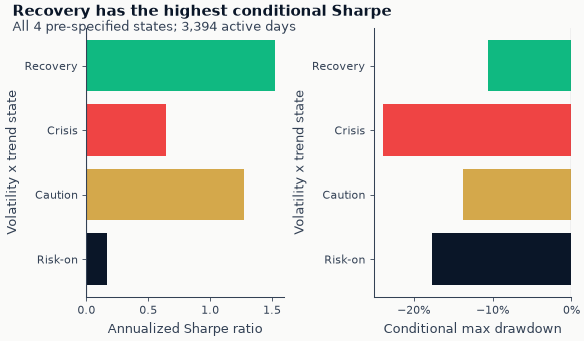

In [18]:
fig, axes = plt.subplots(1, 2)
state_labels = regime_summary["regime"].to_list()
state_colors = [COLORS["blue"], COLORS["amber"], COLORS["negative"], COLORS["positive"]]

axes[0].barh(state_labels, regime_summary["sharpe"], color=state_colors)
axes[0].axvline(0, color=COLORS["neutral"], linewidth=0.8)
axes[0].set_xlabel("Annualized Sharpe ratio")
axes[0].set_ylabel("Volatility x trend state")

axes[1].barh(state_labels, regime_summary["maximum_drawdown"], color=state_colors)
axes[1].axvline(0, color=COLORS["neutral"], linewidth=0.8)
axes[1].set_xlabel("Conditional max drawdown")
axes[1].set_ylabel("Volatility x trend state")
format_pct_axis(axes[1], axis="x")

fig.suptitle(
    f"{highest_sharpe['regime']} has the highest conditional Sharpe",
    x=0.02,
    ha="left",
    color=COLORS["blue"],
    fontweight="bold",
)
fig.text(
    0.02,
    0.91,
    f"All {len(states)} pre-specified states; {active_days:,} active days",
    color=COLORS["neutral"],
)
plt.show()

In [19]:
display(
    Markdown(
        f"""**Reading the state comparison.** {highest_sharpe["regime"]} has the highest
        conditional Sharpe ({highest_sharpe["sharpe"]:.2f}); {lowest_sharpe["regime"]} has the
        lowest ({lowest_sharpe["sharpe"]:.2f}). {deepest_drawdown["regime"]} has the deepest
        conditional-path drawdown ({deepest_drawdown["maximum_drawdown"]:.1%}). The thinnest state,
        {thinnest_state["regime"]}, contains {thinnest_state["days"]:,} days
        ({thinnest_state["share"]:.1%}), so its point estimates carry the most sampling uncertainty.
        These slices describe where returns occurred; they do not identify the mechanism that
        caused them."""
    )
)

**Reading the state comparison.** Recovery has the highest
        conditional Sharpe (1.52); Risk-on has the
        lowest (0.16). Crisis has the deepest
        conditional-path drawdown (-23.9%). The thinnest state,
        Caution, contains 453 days
        (13.3%), so its point estimates carry the most sampling uncertainty.
        These slices describe where returns occurred; they do not identify the mechanism that
        caused them.

## 6. Compare aggregate and crisis tail loss

Value at Risk marks a tail threshold; Conditional Value at Risk averages observations beyond that
threshold. The same estimator is applied to the active sample and the pre-specified Crisis slice.

In [20]:
overall_returns = baseline_returns[active_mask]
crisis_returns = baseline_returns[return_regime == "Crisis"]
overall_var_95 = float(np.quantile(overall_returns, 0.05))
crisis_var_95 = float(np.quantile(crisis_returns, 0.05))
overall_cvar_95 = float(overall_returns[overall_returns <= overall_var_95].mean())
crisis_cvar_95 = float(crisis_returns[crisis_returns <= crisis_var_95].mean())

shared_bins = np.linspace(
    min(overall_returns.min(), crisis_returns.min()),
    max(overall_returns.max(), crisis_returns.max()),
    60,
)

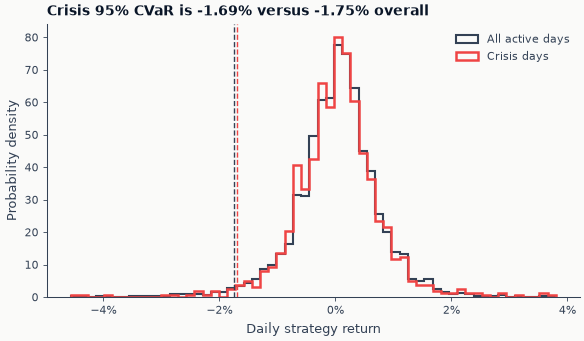

In [21]:
fig, ax = plt.subplots()
ax.hist(
    overall_returns,
    bins=shared_bins,
    density=True,
    histtype="step",
    linewidth=1.5,
    color=COLORS["neutral"],
    label="All active days",
)
ax.hist(
    crisis_returns,
    bins=shared_bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color=COLORS["negative"],
    label="Crisis days",
)
ax.axvline(overall_cvar_95, color=COLORS["neutral"], linestyle="--", linewidth=1)
ax.axvline(crisis_cvar_95, color=COLORS["negative"], linestyle="--", linewidth=1)
ax.set_xlabel("Daily strategy return")
ax.set_ylabel("Probability density")
format_pct_axis(ax, axis="x")
ax.legend(frameon=False)
ax.set_title(
    f"Crisis 95% CVaR is {crisis_cvar_95:.2%} versus {overall_cvar_95:.2%} overall",
    loc="left",
    color=COLORS["blue"],
    fontweight="bold",
)
plt.show()

In [22]:
display(
    Markdown(
        f"""The Crisis tail average is {crisis_cvar_95:.2%}, compared with
        {overall_cvar_95:.2%} for all active days. The {crisis_cvar_95 - overall_cvar_95:.2%}
        difference is descriptive state dependence, not an out-of-sample forecast."""
    )
)

The Crisis tail average is -1.69%, compared with
        -1.75% for all active days. The 0.05%
        difference is descriptive state dependence, not an out-of-sample forecast.

## 7. Attribute the worst calendar drawdown

Simple return sums are not additive through compounding. Log returns are, so summing
$\log(1+r_t)$ by state gives an exact additive attribution of the peak-to-trough growth ratio.

In [23]:
running_peak = np.maximum.accumulate(np.r_[1.0, baseline_growth])[1:]
drawdown = baseline_growth / running_peak - 1
trough_index = int(np.argmin(drawdown))
peak_index = int(np.argmax(baseline_growth[: trough_index + 1]))
episode_mask = np.zeros(len(dates), dtype=bool)
episode_mask[peak_index + 1 : trough_index + 1] = True

episode_frame = pl.DataFrame(
    {
        "regime": return_regime[episode_mask],
        "log_return": np.log1p(baseline_returns[episode_mask]),
    }
)
attribution = (
    episode_frame.group_by("regime")
    .agg(pl.len().alias("days"), pl.col("log_return").sum().alias("log_return_contribution"))
    .sort("log_return_contribution")
)
assert np.isclose(
    attribution["log_return_contribution"].sum(),
    np.log(baseline_growth[trough_index] / baseline_growth[peak_index]),
)

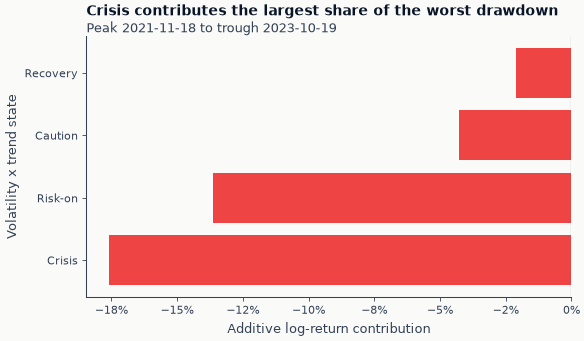

In [24]:
fig, ax = plt.subplots()
colors = [
    COLORS["negative"] if value < 0 else COLORS["positive"]
    for value in attribution["log_return_contribution"]
]
ax.barh(attribution["regime"], attribution["log_return_contribution"], color=colors)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xlabel("Additive log-return contribution")
ax.set_ylabel("Volatility x trend state")
format_pct_axis(ax, axis="x")
largest_loss_state = attribution.row(0, named=True)["regime"]
ax.set_title(
    f"{largest_loss_state} contributes the largest share of the worst drawdown",
    loc="left",
    color=COLORS["blue"],
    fontweight="bold",
    y=1.08,
    pad=0,
)
ax.text(
    0,
    1.015,
    f"Peak {dates[peak_index]} to trough {dates[trough_index]}",
    transform=ax.transAxes,
    color=COLORS["neutral"],
)
plt.show()

In [25]:
display(
    Markdown(
        f"""The worst calendar drawdown runs from {dates[peak_index]} to {dates[trough_index]} and
        reaches {drawdown[trough_index]:.1%}. {largest_loss_state} contributes the most negative
        additive log return during that episode. Attribution identifies when the loss accumulated;
        it does not show that the named state caused the loss."""
    )
)

The worst calendar drawdown runs from 2021-11-18 to 2023-10-19 and
        reaches -31.3%. Crisis contributes the most negative
        additive log return during that episode. Attribution identifies when the loss accumulated;
        it does not show that the named state caused the loss.

## Key Takeaways

In [26]:
display(
    Markdown(
        f"""1. **The diagnostic respects event time.** Each return is classified with volatility and trend
   information available before that return begins.
2. **State dependence is material but descriptive.** Conditional Sharpe ranges from
   {lowest_sharpe["sharpe"]:.2f} in {lowest_sharpe["regime"]} to
   {highest_sharpe["sharpe"]:.2f} in {highest_sharpe["regime"]}.
3. **Coverage controls interpretation.** {thinnest_state["regime"]} has only
   {thinnest_state["days"]:,} observations, so its estimate is less precise than the aggregate.
4. **Tail loss and drawdown answer different questions.** CVaR summarizes bad individual days;
   additive log-return attribution identifies which states accumulated the worst calendar loss.
5. **The input limits remain visible.** The ETF universe is current and hand-curated, while the
   FRED input is a finalized snapshot rather than an ALFRED vintage.

**Next:** `11_sharpe_ratio_inference` quantifies uncertainty around a fixed strategy's Sharpe, and
`14_cost_sensitivity` tests whether the baseline survives alternative fee assumptions.
"""
    )
)

1. **The diagnostic respects event time.** Each return is classified with volatility and trend
   information available before that return begins.
2. **State dependence is material but descriptive.** Conditional Sharpe ranges from
   0.16 in Risk-on to
   1.52 in Recovery.
3. **Coverage controls interpretation.** Caution has only
   453 observations, so its estimate is less precise than the aggregate.
4. **Tail loss and drawdown answer different questions.** CVaR summarizes bad individual days;
   additive log-return attribution identifies which states accumulated the worst calendar loss.
5. **The input limits remain visible.** The ETF universe is current and hand-curated, while the
   FRED input is a finalized snapshot rather than an ALFRED vintage.

**Next:** `11_sharpe_ratio_inference` quantifies uncertainty around a fixed strategy's Sharpe, and
`14_cost_sensitivity` tests whether the baseline survives alternative fee assumptions.
